In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("wine_quality_merged.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [4]:
print("Rows and Columns:", df.shape)

Rows and Columns: (6497, 13)


In [5]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64


In [6]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after removing:", df.duplicated().sum())

Duplicate rows: 1177
Duplicates after removing: 0


In [7]:
print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    5320.000000       5320.000000  5320.000000     5320.000000   
mean        7.215179          0.344130     0.318494        5.048477   
std         1.319671          0.168248     0.147157        4.500180   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.240000        1.800000   
50%         7.000000          0.300000     0.310000        2.700000   
75%         7.700000          0.410000     0.400000        7.500000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  5320.000000          5320.000000           5320.000000  5320.000000   
mean      0.056690            30.036654            114.109023     0.994535   
std       0.036863            17.805045             56.774223     0.002966   
min       0.009000             1.000000         

In [8]:
corr = df.select_dtypes(include=np.number).corr()

print(corr)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000          0.214752     0.330328   
volatile acidity           0.214752          1.000000    -0.384192   
citric acid                0.330328         -0.384192     1.000000   
residual sugar            -0.104439         -0.163696     0.146189   
chlorides                  0.288918          0.367626     0.055199   
free sulfur dioxide       -0.281590         -0.349039     0.130849   
total sulfur dioxide      -0.327471         -0.400716     0.194835   
density                    0.478180          0.308452     0.094758   
pH                        -0.271182          0.246687    -0.344735   
sulphates                  0.304844          0.227772     0.059183   
alcohol                   -0.102573         -0.065411    -0.005496   
quality                   -0.080092         -0.265205     0.097954   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

In [9]:
high_corr = corr[(corr > 0.7) & (corr < 1)]

print(high_corr)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity                   NaN               NaN          NaN   
volatile acidity                NaN               NaN          NaN   
citric acid                     NaN               NaN          NaN   
residual sugar                  NaN               NaN          NaN   
chlorides                       NaN               NaN          NaN   
free sulfur dioxide             NaN               NaN          NaN   
total sulfur dioxide            NaN               NaN          NaN   
density                         NaN               NaN          NaN   
pH                              NaN               NaN          NaN   
sulphates                       NaN               NaN          NaN   
alcohol                         NaN               NaN          NaN   
quality                         NaN               NaN          NaN   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

In [10]:
numeric = df.select_dtypes(include=np.number)

Q1 = numeric.quantile(0.25)
Q3 = numeric.quantile(0.75)
IQR = Q3 - Q1

outliers = ((numeric < (Q1 - 1.5 * IQR)) | (numeric > (Q3 + 1.5 * IQR))).sum()

print(outliers)

fixed acidity           304
volatile acidity        279
citric acid             143
residual sugar          141
chlorides               237
free sulfur dioxide      44
total sulfur dioxide     10
density                   3
pH                       49
sulphates               163
alcohol                   1
quality                 183
dtype: int64


In [11]:
high_quality = df[df["quality"] >= 7]

print(high_quality.head())

    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
7             7.3              0.65         0.00             1.2      0.065   
8             7.8              0.58         0.02             2.0      0.073   
16            8.5              0.28         0.56             1.8      0.092   
37            8.1              0.38         0.28             2.1      0.066   
62            7.5              0.52         0.16             1.9      0.085   

    free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
7                  15.0                  21.0   0.9946  3.39       0.47   
8                   9.0                  18.0   0.9968  3.36       0.57   
16                 35.0                 103.0   0.9969  3.30       0.75   
37                 13.0                  30.0   0.9968  3.23       0.73   
62                 12.0                  35.0   0.9968  3.38       0.62   

    alcohol  quality type  
7      10.0        7  red  
8       9.5       

In [12]:
sorted_df = df.sort_values(by="quality", ascending=False)

print(sorted_df.head())

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
2373            9.1              0.27         0.45            10.6      0.035   
2419            6.6              0.36         0.29             1.6      0.021   
3204            7.1              0.26         0.49             2.2      0.032   
2475            6.9              0.36         0.34             4.2      0.018   
2426            7.4              0.24         0.36             2.0      0.031   

      free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
2373                 28.0                 124.0  0.99700  3.20       0.46   
2419                 24.0                  85.0  0.98965  3.41       0.61   
3204                 31.0                 113.0  0.99030  3.37       0.42   
2475                 57.0                 119.0  0.98980  3.28       0.36   
2426                 27.0                 139.0  0.99055  3.28       0.48   

      alcohol  quality   type  
2373     10.4     

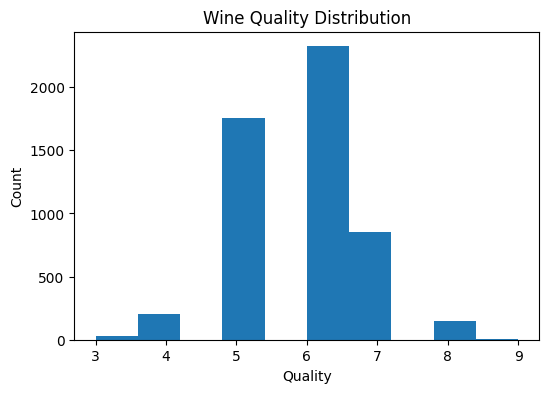

In [13]:
plt.figure(figsize=(6,4))
plt.hist(df["quality"], bins=10)
plt.title("Wine Quality Distribution")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

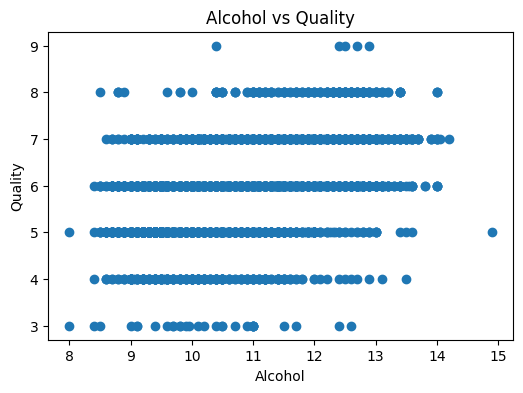

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(df["alcohol"], df["quality"])
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Alcohol vs Quality")
plt.show()

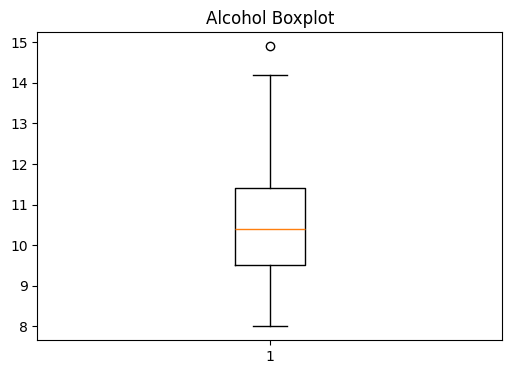

In [15]:
plt.figure(figsize=(6,4))
plt.boxplot(df["alcohol"])
plt.title("Alcohol Boxplot")
plt.show()

In [16]:
print("Business Insight Report")
print("- Wines with higher alcohol content generally have better quality.")
print("- Some numerical features show moderate correlation.")
print("- Outliers are present in a few numerical columns.")
print("- Duplicate records were removed before analysis.")
print("- The dataset is useful for predicting wine quality.")

Business Insight Report
- Wines with higher alcohol content generally have better quality.
- Some numerical features show moderate correlation.
- Outliers are present in a few numerical columns.
- Duplicate records were removed before analysis.
- The dataset is useful for predicting wine quality.


In [17]:
print("EDA Summary")
print("I explored the Wine Quality dataset by checking missing values, duplicates, descriptive statistics, correlation, outliers and visualizations. I observed that alcohol has a positive relationship with wine quality. After cleaning the data and analyzing different features, I understood the important factors that affect wine quality.")

EDA Summary
I explored the Wine Quality dataset by checking missing values, duplicates, descriptive statistics, correlation, outliers and visualizations. I observed that alcohol has a positive relationship with wine quality. After cleaning the data and analyzing different features, I understood the important factors that affect wine quality.
